# Detección de fraude en transacciones con tarjeta — enfoque supervisado

**Problema.** Clasificar transacciones fraudulentas sobre un conjunto con desbalanceo
extremo de clases, donde el coste de un falso negativo (fraude no detectado) y el de un
falso positivo (cliente legítimo bloqueado) no son simétricos.

**Enfoque.** Regresión logística con ponderación de clases, evaluada con métricas
adecuadas al desbalanceo (recall, precision, curva Precision-Recall) en lugar de exactitud.

**Stack.** Python · pandas · scikit-learn · matplotlib · seaborn

> El notebook complementario `fraude_no_supervisado.ipynb` aborda el mismo problema
> sin usar la etiqueta, mediante DBSCAN e Isolation Forest.

---

> **Datos.** Este notebook utiliza el conjunto *Credit Card Fraud Detection* del grupo de
> Machine Learning de la Université Libre de Bruxelles, disponible públicamente en
> [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) bajo licencia
> Database Contents License v1.0. Contiene 284.807 transacciones de tarjetas europeas,
> de las cuales 492 son fraudulentas (0,172%). Las variables `V1`–`V28` son componentes
> principales obtenidas por PCA para preservar la confidencialidad; `Amount` y `Class`
> son las únicas no transformadas.
>
> El fichero no se incluye en el repositorio por tamaño: descárgalo de Kaggle y cárgalo
> cuando el notebook lo solicite.

## 1. Carga de datos

El dataset de transacciones no se publica en el repositorio. La celda siguiente permite
cargarlo manualmente al ejecutar el notebook en Colab.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fraude_csv.csv to fraude_csv.csv


In [ ]:
import pandas as pd

df = pd.read_csv("fraude_csv.csv", sep=";")
print(df.head(10))
df.columns


         V1        V2        V3        V4        V5        V6        V7  \
0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545 -2.537387   
1 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823  0.325574   
2 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788  0.562320   
3 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536 -3.496197   
4  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746  1.713445   
5  0.008430  4.137837 -6.240697  6.675732  0.768307 -3.353060 -1.631735   
6  0.026779  4.132464 -6.560600  6.348557  1.329666 -2.513479 -1.689102   
7  0.329594  3.712889 -5.775935  6.078266  1.667359 -2.420168 -0.812891   
8  0.316459  3.809076 -5.615159  6.047445  1.554026 -2.651353 -0.746579   
9  0.725646  2.300894 -5.329976  4.007683 -1.730411 -1.732193 -3.968593   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  1.391657 -2.770089 -2.772272  ...  0.517232 -0.035049 -0.465211  0.320198   
1 -0.067794 -0

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

## 2. Exploración inicial

Dimensiones, tipos de dato, ausentes y —lo determinante en este problema— la distribución
de la variable objetivo `Class`, fuertemente desbalanceada.

In [ ]:
print(df.shape)
print(df.dtypes)
print(df["Class"].value_counts())
print(df.isnull().sum())

(10492, 30)
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Class
0    10000
1      492
Name: count, dtype: int64
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 3. Dispersión de las variables anonimizadas

Las variables `V1`–`V28` son componentes anonimizadas. Se ordenan por rango intercuartílico
para identificar cuáles concentran mayor dispersión.

In [ ]:
v_cols = [col for col in df.columns if col.startswith("V")]

desc_v = df[v_cols].describe().T

# Añadimos métricas útiles
desc_v["rango"] = desc_v["max"] - desc_v["min"]
desc_v["Q1"] = df[v_cols].quantile(0.25)
desc_v["Q3"] = df[v_cols].quantile(0.75)
desc_v["IQR"] = desc_v["Q3"] - desc_v["Q1"]
top_iqr = desc_v.sort_values(by="IQR", ascending=False).head(5)
print(top_iqr)

       count      mean       std        min       25%       50%       75%  \
V1   10492.0 -0.253891  2.653492 -34.591213 -1.042351 -0.089763  1.293633   
V3   10492.0 -0.316120  2.577539 -31.103685 -1.058140  0.109849  1.004156   
V4   10492.0  0.189900  1.784402  -5.519697 -0.828834  0.052344  0.864884   
V11  10492.0  0.161461  1.394021  -3.881222 -0.736955  0.034411  0.818436   
V2   10492.0  0.139075  2.085015 -48.060856 -0.592149  0.097423  0.878073   

           max      rango        Q1        Q3       IQR  
V1    2.399241  36.990454 -1.042351  1.293633  2.335984  
V3    3.971381  35.075066 -1.058140  1.004156  2.062296  
V4   12.114672  17.634369 -0.828834  0.864884  1.693718  
V11  12.018913  15.900136 -0.736955  0.818436  1.555391  
V2   22.057729  70.118585 -0.592149  0.878073  1.470222  


## 4. Análisis de la variable Amount

El importe es la única variable con significado económico directo. Su asimetría condiciona
la necesidad de estandarizar antes de entrenar.

In [ ]:
print(df["Amount"].describe())
print("Asimetría:", df["Amount"].skew())

count    10492.000000
mean        91.020633
std        235.886571
min          0.000000
25%          5.000000
50%         20.990000
75%         78.950000
max       7712.430000
Name: Amount, dtype: float64
Asimetría: 9.518631182381924


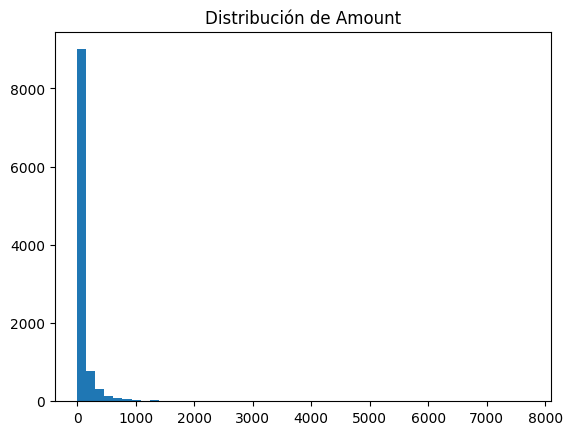

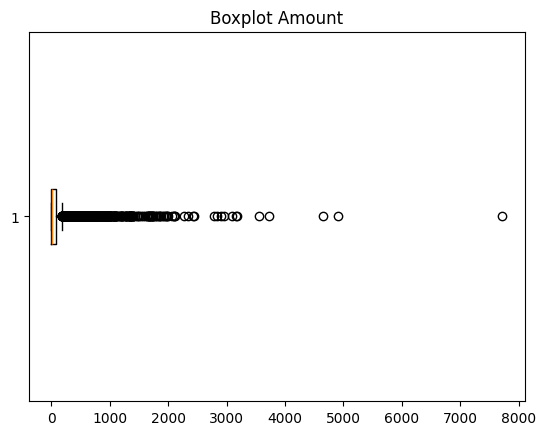

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Amount"], bins=50)
plt.title("Distribución de Amount")
plt.show()

plt.boxplot(df["Amount"], vert=False)
plt.title("Boxplot Amount")
plt.show()

## 5. Partición estratificada

Con una clase minoritaria tan reducida, la partición debe ser estratificada: de lo contrario
el conjunto de test puede quedarse casi sin casos de fraude y las métricas dejan de ser fiables.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 6. Estandarización

El escalador se ajusta **solo** sobre el conjunto de entrenamiento y se aplica al de test,
para evitar fuga de información.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Modelo: regresión logística con ponderación de clases

Se usa `class_weight="balanced"` para compensar el desbalanceo sin recurrir a remuestreo,
manteniendo la interpretabilidad del modelo — un requisito habitual en entornos regulados.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 8. Evaluación

En detección de fraude la exactitud global es engañosa: un modelo que prediga siempre
"legítima" acertaría en más del 99% de los casos. Las métricas relevantes son recall
(fraude que se deja escapar) y precision (falsas alarmas sobre clientes legítimos).

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("F1:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9854001570643249
F1: 0.788135593220339
Recall: 0.9489795918367347
Precision: 0.6739130434782609
Confusion Matrix:
 [[1956   45]
 [   5   93]]


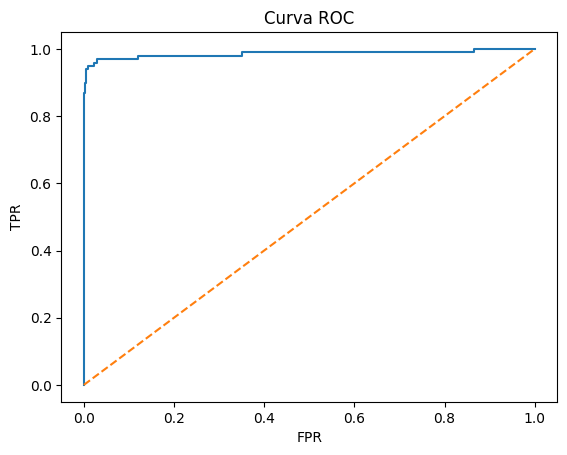

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

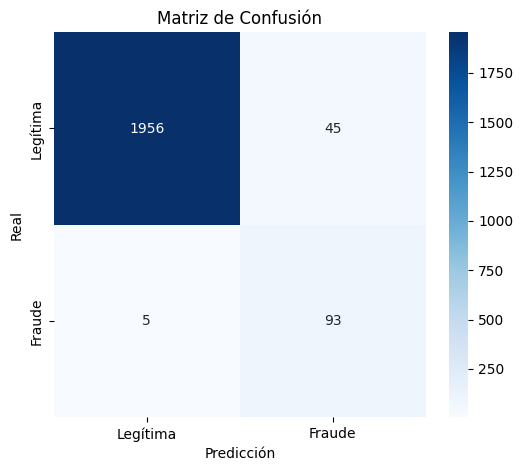

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legítima", "Fraude"],
            yticklabels=["Legítima", "Fraude"])

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

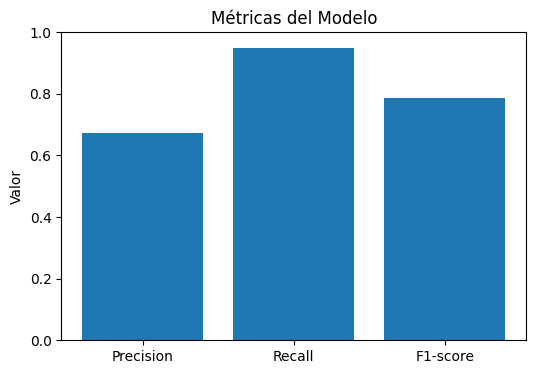

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

metrics = {
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0,1)
plt.title("Métricas del Modelo")
plt.ylabel("Valor")
plt.show()

## 9. Curva Precision-Recall

Más informativa que la ROC cuando la clase positiva es minoritaria. Permite elegir el umbral
según el coste relativo de cada tipo de error.

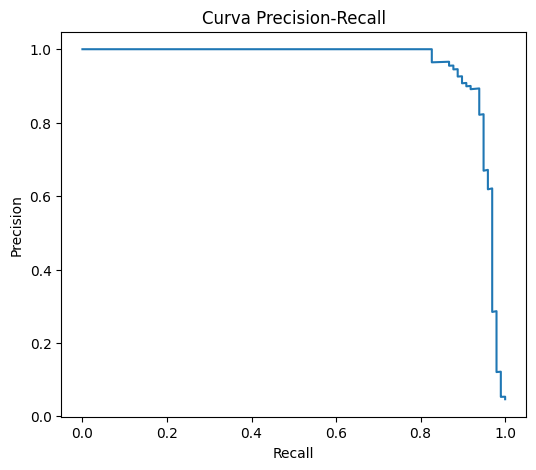

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

## 10. Variables más influyentes

Magnitud de los coeficientes del modelo. Al estar las variables estandarizadas, los
coeficientes son comparables entre sí.

[('V14', np.float64(2.105322113408779)), ('V12', np.float64(1.9339528713159144)), ('V4', np.float64(1.4717451168515236)), ('V17', np.float64(1.2520320458055143)), ('V10', np.float64(1.2483702543414477)), ('Amount', np.float64(1.0302423410424206)), ('V1', np.float64(1.0225058178768083)), ('V8', np.float64(0.8713239824998602)), ('V16', np.float64(0.8499035387224396)), ('V5', np.float64(0.7539586668730021))]


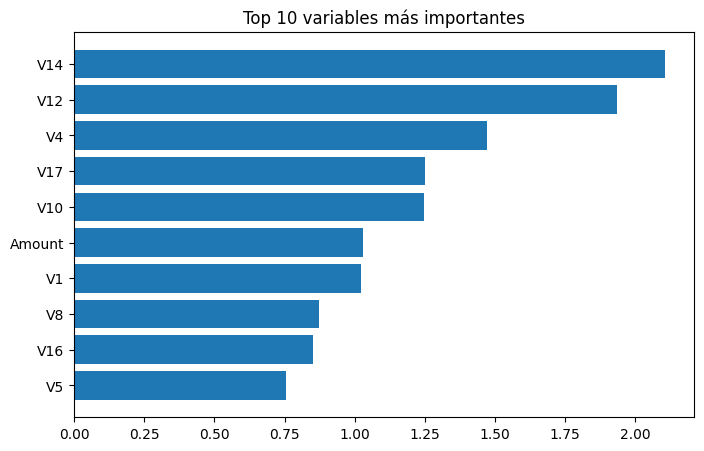

In [ ]:
import numpy as np

coef = np.abs(model.coef_[0])
features = X.columns

importance = sorted(zip(features, coef), key=lambda x: x[1], reverse=True)[:10]

print(importance)

# Gráfico
vars_ = [x[0] for x in importance]
vals_ = [x[1] for x in importance]

plt.figure(figsize=(8,5))
plt.barh(vars_, vals_)
plt.title("Top 10 variables más importantes")
plt.gca().invert_yaxis()
plt.show()